In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
img_size = 224
batch_size = 32
epochs = 15

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
train_generator = train_datagen.flow_from_directory(
    "/content/drive/MyDrive/Colab Notebooks/brain_dataset/train",
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

Found 203 images belonging to 2 classes.


In [6]:
val_generator = train_datagen.flow_from_directory(
    "/content/drive/MyDrive/Colab Notebooks/brain_dataset/train",
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 50 images belonging to 2 classes.


In [7]:
model = models.Sequential()

In [8]:
model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)))
model.add(layers.Conv2D(32,(3,3),activation='relu'))
model.add(layers.MaxPooling2D(2,2))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D(2,2))

In [11]:
model.add(layers.Conv2D(128,(3,3),activation='relu'))
model.add(layers.MaxPooling2D(2,2))

In [12]:
model.add(layers.Flatten())

In [13]:
model.add(layers.Dense(256,activation='relu'))
model.add(layers.Dropout(0.5))

In [14]:
model.add(layers.Dense(2,activation='softmax'))

In [15]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [17]:
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator,
    callbacks=[early_stop]
)

Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 6s/step - accuracy: 0.5961 - loss: 0.6592 - val_accuracy: 0.6200 - val_loss: 0.6156
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 6s/step - accuracy: 0.6108 - loss: 0.6512 - val_accuracy: 0.6600 - val_loss: 0.5973
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 38s 5s/step - accuracy: 0.6700 - loss: 0.6196 - val_accuracy: 0.7200 - val_loss: 0.5767
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 38s 5s/step - accuracy: 0.6946 - loss: 0.6060 - val_accuracy: 0.6600 - val_loss: 0.5533
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 38s 6s/step - accuracy: 0.7291 - loss: 0.6007 - val_accuracy: 0.8000 - val_loss: 0.5012
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 38s 5s/step - accuracy: 0.7241 - loss: 0.5800 - val_accuracy: 0.7200 - val_loss: 0.5701
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 38s 5s/step - accuracy: 0.7389 - loss: 0.5620 - val_accuracy: 0.6600 - val_loss: 0.6237
Epoch 8/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 38s 5s/step - accuracy: 0.7291 - loss: 0.5543 - val_accuracy: 0.7600 - val_loss: 0.5674


In [18]:
loss, accuracy = model.evaluate(val_generator)
print("Validation Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 771ms/step - accuracy: 0.7200 - loss: 0.5760
Validation Accuracy: 0.7200000286102295


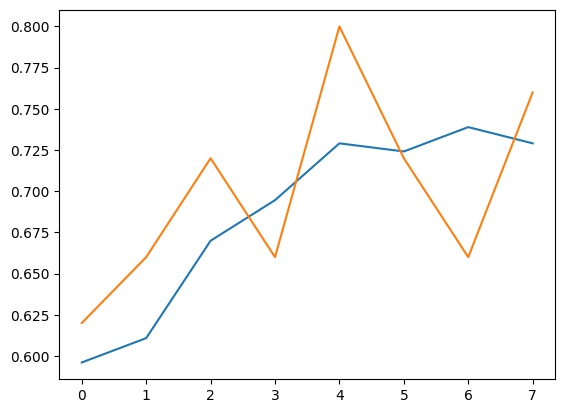

In [19]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

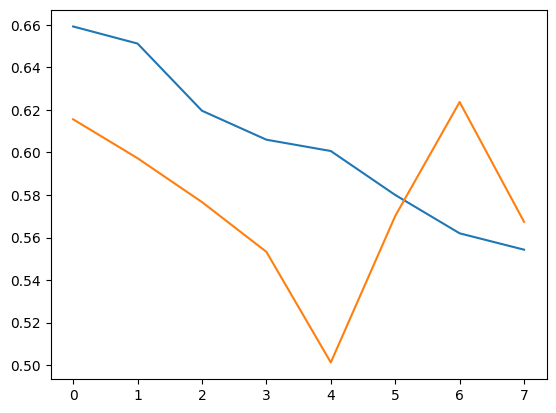

In [20]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')